# **Customer Segmentation Using Unsupervised Learning Models**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Optional: to ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
#drive.mount('/content/drive')

**STEP 1: READ DATASET**

In [ ]:
# 1. Load data
df = pd.read_csv("/content/sample_data/Mall_Customers.csv")

**STEP 2: Explore data**

In [ ]:
# 2. Explore data
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nDataset info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())


First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape of dataset:
(200, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

**STEP 3: Select features**

In [ ]:
# 3. Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

**STEP 4: Visualize raw data**

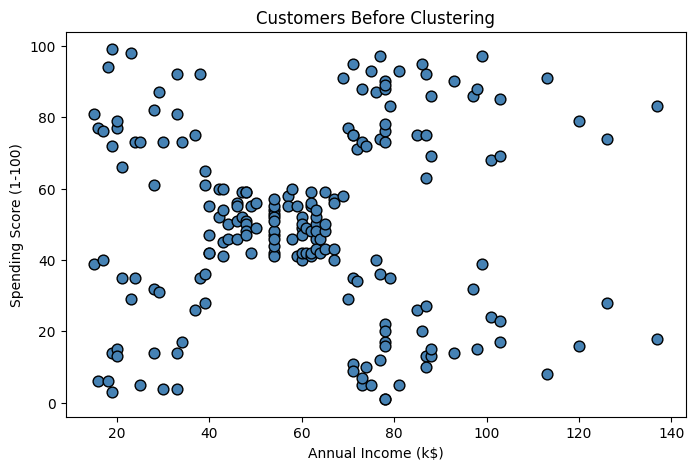

In [ ]:
# 4. Visualize raw data
plt.figure(figsize=(8, 5))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    color='steelblue',
    s=60,
    edgecolor='black'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers Before Clustering")
plt.show()

**STEP 5: Scale features**

In [ ]:
# 5. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**STEP 6: Elbow method**

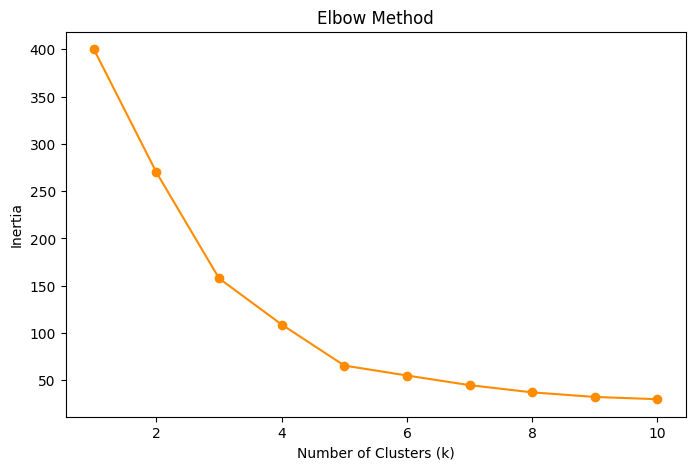

In [ ]:
# 6. Elbow method
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', color='darkorange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


**STEP 7: Train final model**

In [ ]:
# 7. Train final model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

**STEP 8: Check cluster averages before naming them**

In [ ]:

# 8. Check cluster averages before naming them
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("\nCluster Means:")
print(cluster_summary)

print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())



Cluster Means:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043

Cluster Sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


**STEP 9: Define cluster labels based on the output above**

In [ ]:
# 9. Define cluster labels based on the output above
cluster_labels = {
    0: "Average Customers",
    1: "High Income - High Spending",
    2: "Low Income - High Spending",
    3: "High Income - Low Spending",
    4: "Low Income - Low Spending"
}

**STEP 10: Colors for clusters**

In [ ]:
# 10. Colors for clusters
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

**STEP 11: Visualize clusters with meaningful legend**

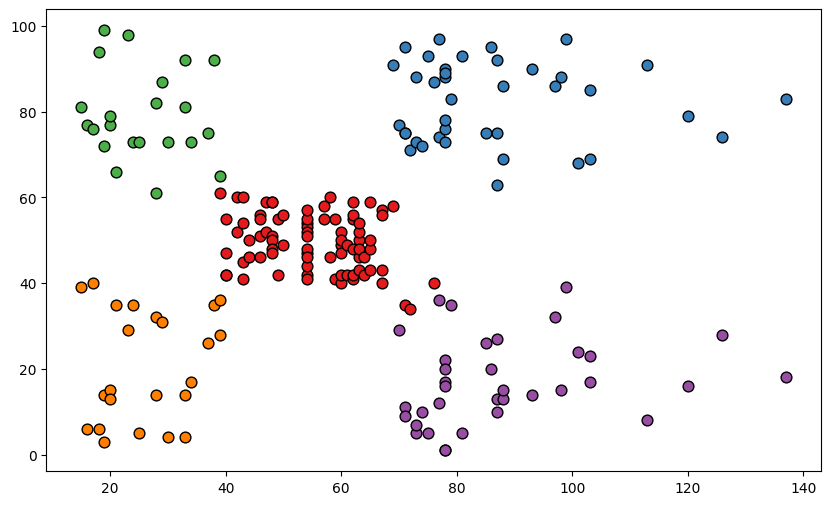

In [ ]:

# 11. Visualize clusters with meaningful legend
plt.figure(figsize=(10, 6))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        color=colors[i],
        s=60,
        edgecolor='black',
        label=cluster_labels[i]
    )

**STEP 12: Plot centroids**

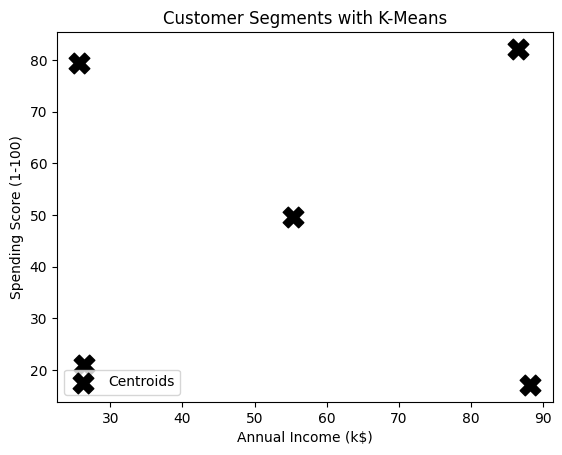

In [ ]:
# 12. Plot centroids
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    s=220,
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments with K-Means")
plt.legend()
plt.show()